In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
df = pd.read_csv("heart.csv")

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (918, 12)


In [ ]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


In [ ]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()

print("\nNumerical features:", numerical_features)
print("Categorical features:", categorical_features)


Numerical features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
Categorical features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [ ]:
# Missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Cholesterol"] = df["Cholesterol"].fillna(df["Cholesterol"].median())
df["Sex"] = df["Sex"].fillna(df["Sex"].mode()[0])

# Missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Duplicate check
print("\nDuplicate rows:", df.duplicated().sum())

# Summary statistics
df.describe()

Missing values before cleaning:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Missing values after cleaning:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicate rows: 0


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


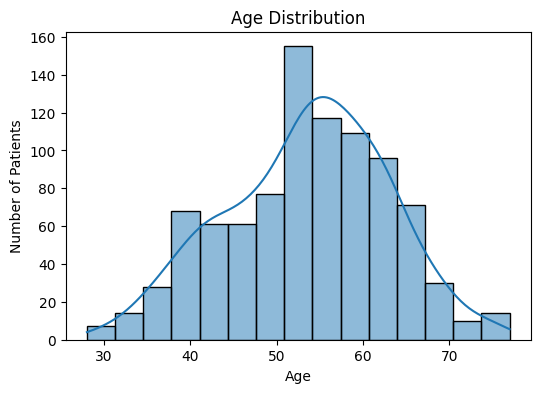

In [ ]:
#HISTOGRAM
plt.figure(figsize=(6,4))

sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()



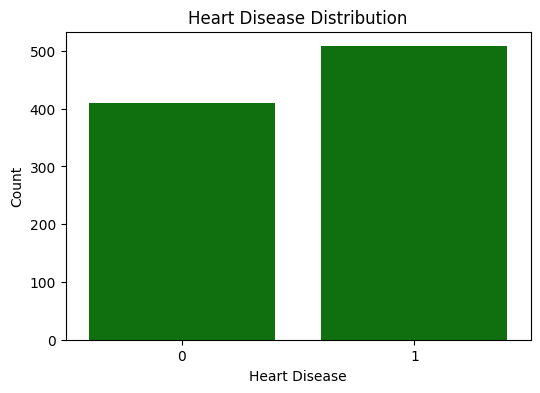

In [ ]:
#COUNT PLOT
plt.figure(figsize=(6,4))

sns.countplot(x="HeartDisease", data=df, color="green")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

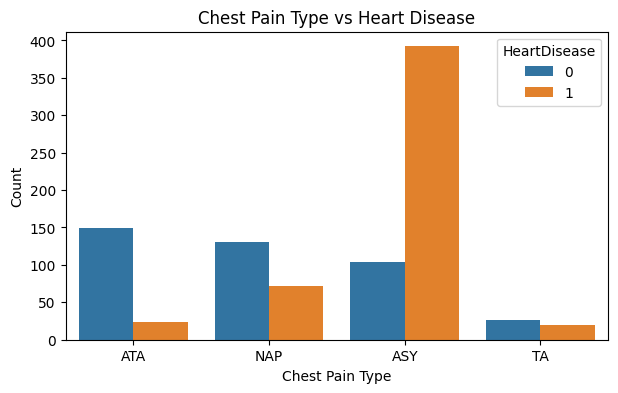

In [ ]:
plt.figure(figsize=(7,4))

sns.countplot(x="ChestPainType", hue="HeartDisease", data=df)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")

plt.show()

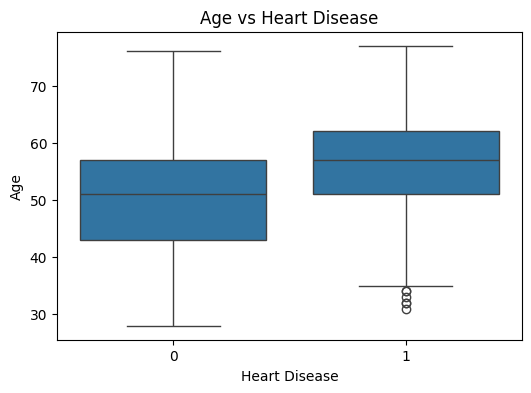

In [ ]:
#BOX PLOT
plt.figure(figsize=(6,4))

sns.boxplot(x="HeartDisease", y="Age", data=df)

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.show()

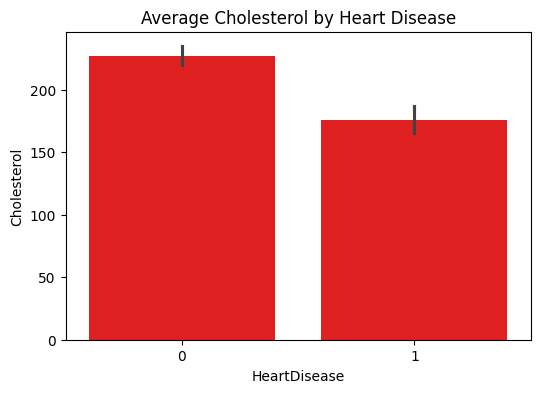

In [ ]:
#BAR PLOT
plt.figure(figsize=(6,4))

sns.barplot(x="HeartDisease", y="Cholesterol", data=df, color="red")

plt.title("Average Cholesterol by Heart Disease")

plt.show()

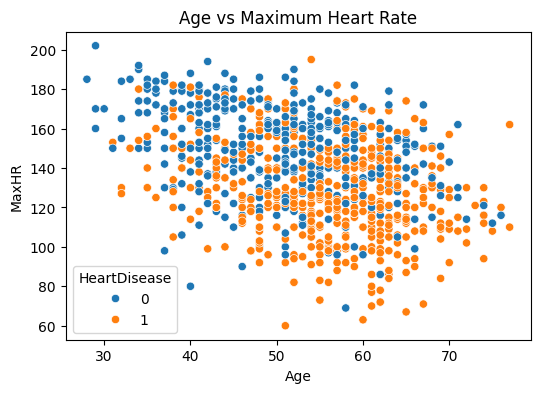

In [ ]:
#SCATTER PLOT
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Age",
    y="MaxHR",
    hue="HeartDisease",
    data=df
)

plt.title("Age vs Maximum Heart Rate")
plt.show()

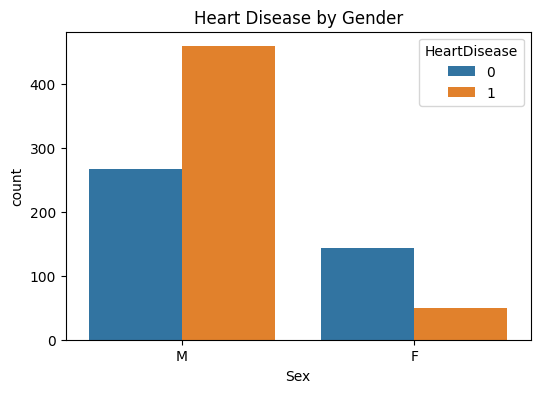

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Sex",
    hue="HeartDisease",
    data=df
)

plt.title("Heart Disease by Gender")

plt.show()

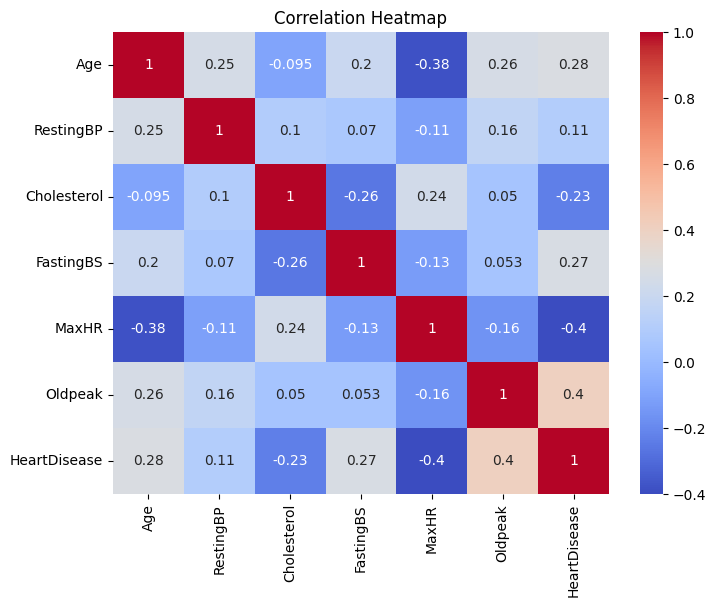

In [ ]:
# CALCULATE CORRELATION
corr = df.corr(numeric_only=True)

# PLOT HEATMAP
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# ==========================
# DATA INSIGHTS
# ==========================

print("Average Age:", round(df["Age"].mean()))
print("Median Age:", df["Age"].median())

print("\nGender Distribution")
print(df["Sex"].value_counts())

print("\nChest Pain Type Distribution")
print(df["ChestPainType"].value_counts())

print("\nHeart Disease Distribution")
print(df["HeartDisease"].value_counts())

print("\nAverage Cholesterol:", round(df["Cholesterol"].mean()))

print("\nAverage Age by Heart Disease")
print(df.groupby("HeartDisease")["Age"].mean())

print("\nAverage Cholesterol by Heart Disease")
print(df.groupby("HeartDisease")["Cholesterol"].mean())

print("\nAverage Maximum Heart Rate by Heart Disease")
print(df.groupby("HeartDisease")["MaxHR"].mean())

Average Age: 54
Median Age: 54.0

Gender Distribution
Sex
M    725
F    193
Name: count, dtype: int64

Chest Pain Type Distribution
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

Heart Disease Distribution
HeartDisease
1    508
0    410
Name: count, dtype: int64

Average Cholesterol: 199

Average Age by Heart Disease
HeartDisease
0    50.551220
1    55.899606
Name: Age, dtype: float64

Average Cholesterol by Heart Disease
HeartDisease
0    227.121951
1    175.940945
Name: Cholesterol, dtype: float64

Average Maximum Heart Rate by Heart Disease
HeartDisease
0    148.151220
1    127.655512
Name: MaxHR, dtype: float64


#CONCLUSION

* The dataset contains information on 918 patients with 12 clinical features.
* The majority of patients in the dataset are male.
*   Asymptomatic (ASY) chest pain is the most common chest pain type among patients with heart disease.

*  The average age of patients with heart disease is higher than that of patients without heart disease.








